# Phase A — Comprehensive Industry Exploration
### IRA Kenya Quarterly Insurance Statistics | Q1 2024 – Q1 2026 (9 quarters)

This notebook compiles the full Phase A distribution-exploration work: P&L/IFRS 17
profitability, loss ratio & underwriting performance, and market share/concentration —
each following the same 7-part exploration template, built on the live `fact_pl` table
pulled from Supabase Postgres.

**Locked-in scope decisions from this phase:**
1. **Profitability layer = IFRS 17 only** (`PL_GB_SUMMARY`, `PL_LT_SUMMARY`,
   `PL_MICRO_SUMMARY`). It's the one framework genuinely comparable across GB/LT/Micro —
   that's the whole point of IFRS 17 superseding fund accounting and underwriting-account
   accounting with one recognition standard.
2. **Loss ratio / underwriting layer** uses the `*_COMBINED_PREMIUM_SUMMARY` rows
   (GB + Micro only — LT has no equivalent, by design, since LT is fund-accounted).
3. **IRA's quarterly figures are cumulative year-to-date**, not discrete standalone-quarter
   figures — confirmed against IRA's own published report titles ("January–March" = Q1,
   "January–June" = Q2, etc.) and cross-checked numerically against a published IRA total.
   Both a **YTD view** (as reported) and a **de-cumulated discrete-quarter view** are built
   throughout, since they answer different questions: YTD tells you standing-to-date,
   discrete tells you what actually happened *in* that quarter.
4. **A zero following a positive cumulative figure earlier in the same year is treated as
   missing, not a real zero**, before de-cumulating — this avoids spurious negative
   "discrete quarter" values that would otherwise look like impossible premium reversals.

**Not yet included:** none — this revision adds Part 4 (balance sheet/solvency), now built
from the real `fact_balance_sheet` Postgres export (long/EAV format, pivoted here) rather
than a manual Excel extraction, and covering the full 9-quarter history rather than just
Q1 snapshots.

**Data-quality note carried in from this revision:** six placeholder rows (`GRAND TOTAL`,
`Reinsurers`, `TOTAL`, `Insurers`, `TOTAL INSURERS`, `MICROINSURERS` — section-header/
subtotal labels from the source appendices) were found loaded into `dim_company` as if
they were real companies, and are excluded here. **The same placeholder `company_id`s are
also present in `fact_pl`** (49 rows, confirmed) — Parts 1–3 of this notebook do not yet
have this fix applied and should be treated as provisional until they do. In particular,
the GB revenue outlier flagged in Part 1 (63.5M, described there as needing
investigation) has since been confirmed to be the `GRAND TOTAL` row, not a real company.


## Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os 
from sqlalchemy import create_engine,text
from dotenv import load_dotenv
load_dotenv()
engine= create_engine(os.getenv('DATABASE_URL'), echo=False, future=True)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ---- CONFIG ----
FACT_PL_PATH = 'fact_pl.csv'
DIM_COMPANY_PATH = 'dim_company_rows.csv'
FACT_BALANCE_SHEET_PATH = 'fact_balance_sheet_rows.csv'  # long/EAV export from Postgres

# period_id -> (year, quarter, label). TODO: replace with a real dim_period join
# once that table is exportable — this is a hand-typed stand-in.
PERIOD_META = {
    7: (2024,1,'2024Q1'), 10:(2024,2,'2024Q2'), 13:(2024,3,'2024Q3'), 16:(2024,4,'2024Q4'),
    1: (2025,1,'2025Q1'), 5: (2025,2,'2025Q2'), 23:(2025,3,'2025Q3'), 26:(2025,4,'2025Q4'),
    29:(2026,1,'2026Q1'),
}
QUARTER_ORDER = ['2024Q1','2024Q2','2024Q3','2024Q4','2025Q1','2025Q2','2025Q3','2025Q4','2026Q1']

COLORS = {'GB':'#2563eb','LT':'#16a34a','Micro':'#dc2626'}


## Load & prepare

`fact_pl` carries multiple row *shapes* per company/period, distinguished by
`source_fingerprint_id`. We split into the IFRS 17 rows (profitability) and the
combined-premium rows (loss ratio/underwriting/market share) up front.

In [38]:
raw = pd.read_sql("select * from fact_pl",engine)
dim_company = pd.read_sql("select * from dim_company",engine)
PLACEHOLDER_IDS = [17, 46, 216, 247, 1032, 1054]  # GRAND TOTAL, Reinsurers, TOTAL, Insurers, TOTAL INSURERS, MICROINSURERS
raw = raw[~raw.company_id.isin(PLACEHOLDER_IDS)]

print('Raw shape:', raw.shape)
print(raw['source_fingerprint_id'].value_counts())

def attach_period_and_company(frame):
    frame = frame.copy()
    frame['year'] = frame['period_id'].map(lambda p: PERIOD_META.get(p, (None,None,None))[0])
    frame['q'] = frame['period_id'].map(lambda p: PERIOD_META.get(p, (None,None,None))[1])
    frame['quarter'] = frame['period_id'].map(lambda p: PERIOD_META.get(p, (None,None,None))[2])
    frame = frame.merge(dim_company[['company_id','company_name']], on='company_id', how='left')
    assert frame['quarter'].notna().all(), 'Unmapped period_id found — check PERIOD_META'
    assert frame['company_name'].notna().all(), 'Unmapped company_id found — check dim_company'
    return frame

IFRS17_FINGERPRINTS = ['PL_GB_SUMMARY','PL_LT_SUMMARY','PL_MICRO_SUMMARY']
UW_FINGERPRINTS = ['GB_COMBINED_PREMIUM_SUMMARY','MICRO_COMBINED_PREMIUM_SUMMARY']

ifrs = attach_period_and_company(raw[raw.source_fingerprint_id.isin(IFRS17_FINGERPRINTS)])
uw   = attach_period_and_company(raw[raw.source_fingerprint_id.isin(UW_FINGERPRINTS)])

ifrs['margin'] = ifrs['insurance_service_result'] / ifrs['insurance_revenue']
print()
print('IFRS17 rows:', ifrs.shape, '| Underwriting rows:', uw.shape)


Raw shape: (1087, 34)
source_fingerprint_id
PL_GB_SUMMARY                     380
GB_COMBINED_PREMIUM_SUMMARY       380
PL_LT_SUMMARY                     257
PL_MICRO_SUMMARY                   35
MICRO_COMBINED_PREMIUM_SUMMARY     35
Name: count, dtype: int64

IFRS17 rows: (672, 39) | Underwriting rows: (415, 38)


In [39]:
def decumulate(frame, value_col, out_col):
    """Convert cumulative YTD figures to discrete-quarter figures.
    A zero following a positive cumulative value earlier in the same year is treated
    as missing (non-submission), not a real zero, before diffing — otherwise a
    later-quarter non-submission looks like an impossible negative discrete value.
    Vectorized (no groupby.apply) to avoid a pandas quirk that can silently drop the
    grouping columns from the result on chained calls."""
    frame = frame.sort_values(['company_id','year','q']).reset_index(drop=True).copy()
    frame['_val'] = frame[value_col]
    prior_max = frame.groupby(['company_id','year'])['_val'].transform(lambda s: s.shift().cummax())
    zero_after_positive = (frame['_val'] == 0) & (prior_max > 0)
    frame.loc[zero_after_positive, '_val'] = np.nan
    frame[out_col] = frame.groupby(['company_id','year'])['_val'].diff()
    frame.loc[frame['q']==1, out_col] = frame.loc[frame['q']==1, '_val']
    frame = frame.drop(columns='_val')
    return frame


---
# Part 1 — P&L / IFRS 17 Profitability (GB / LT / Micro)

### 1.1 Univariate distributions (raw scale, 2026Q1)

In [40]:
latest_ifrs = ifrs[ifrs['quarter']=='2026Q1']

def univariate(frame, col):
    g = frame.groupby('segment')[col]
    return pd.DataFrame({'n':g.count(),'min':g.min(),'median':g.median(),'mean':g.mean(),'max':g.max()}).round(0)

print('Insurance Revenue — 2026Q1')
display(univariate(latest_ifrs, 'insurance_revenue'))
print('Insurance Service Result — 2026Q1')
display(univariate(latest_ifrs, 'insurance_service_result'))


Insurance Revenue — 2026Q1


,n,min,median,mean,max
segment,,,,,
GB,40,0.00,"953,884.00","1,587,672.00","5,156,202.00"
LT,25,0.00,"524,490.00","870,954.00","3,983,747.00"
Micro,6,0.00,"2,852.00","84,356.00","367,803.00"


Insurance Service Result — 2026Q1


,n,min,median,mean,max
segment,,,,,
GB,40,"-699,775.00","46,265.00","47,527.00","447,348.00"
LT,25,"-192,297.00","29,035.00","82,233.00","847,589.00"
Micro,6,"-10,853.00",0.00,"9,931.00","58,373.00"


### 1.2 Derived ratio — underwriting margin (ISR ÷ Revenue)

,n,p25,median,p75,mean,pct_negative
segment,,,,,,
GB,37,-0.00,0.04,0.12,0.03,0.24
LT,22,-0.05,0.08,0.16,0.23,0.31
Micro,3,-0.94,0.03,0.24,-0.48,0.14


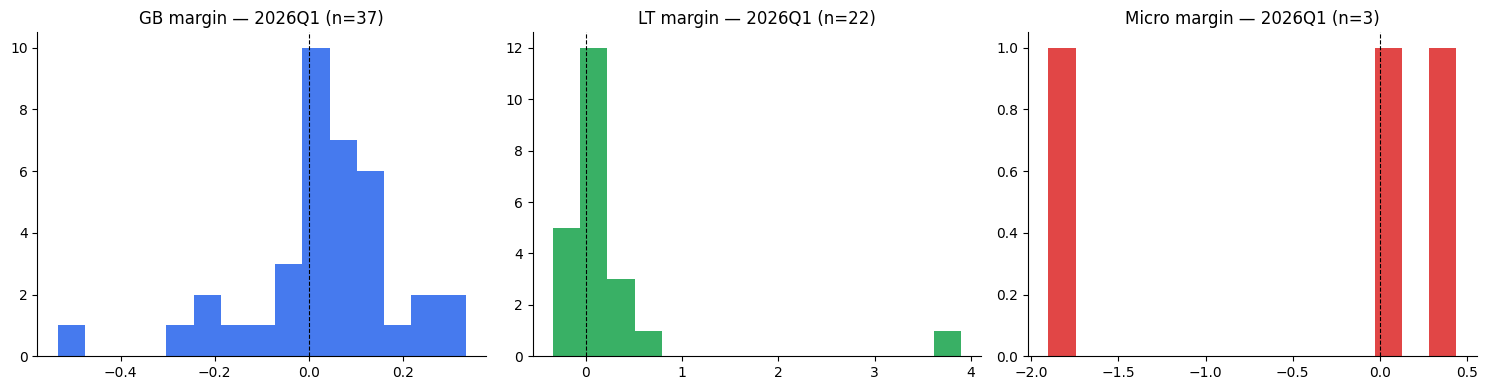

In [41]:
def margin_summary(frame):
    g = frame.groupby('segment')['margin']
    return pd.DataFrame({
        'n': g.count(), 'p25': g.quantile(.25), 'median': g.median(),
        'p75': g.quantile(.75), 'mean': g.mean(),
        'pct_negative': frame.groupby('segment')['margin'].apply(lambda s: (s<0).mean()),
    }).round(3)

display(margin_summary(latest_ifrs))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, seg in zip(axes, ['GB','LT','Micro']):
    vals = latest_ifrs.loc[latest_ifrs.segment==seg, 'margin'].dropna()
    ax.hist(vals, bins=15, color=COLORS[seg], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{seg} margin — 2026Q1 (n={len(vals)})')
plt.tight_layout(); plt.show()


### 1.3 Outlier flagging (revenue-floor filtered — 10th percentile per segment)

In [42]:
def flag_outliers(frame, seg, n=5):
    sub = frame[frame.segment==seg].copy()
    floor = sub['insurance_revenue'].quantile(0.10)
    sub = sub[sub['insurance_revenue'] >= floor]
    cols = ['company_name','insurance_revenue','insurance_service_result','margin']
    print(f'--- {seg} (floor={floor:,.0f}) ---')
    print('Worst:'); display(sub.nsmallest(n,'margin')[cols])
    print('Best:'); display(sub.nlargest(n,'margin')[cols])

for seg in ['GB','LT','Micro']:
    flag_outliers(latest_ifrs, seg)


--- GB (floor=280,527) ---
Worst:


,company_name,insurance_revenue,insurance_service_result,margin
617,KENYA ORIENT INSURANCE,"348,864.15","-186,322.61",-0.53
622,OCCIDENTAL INSURANCE COMPANY,"398,418.88","-106,596.63",-0.27
615,JUBILEE HEALTH INSURANCE,"3,465,527.63","-699,775.01",-0.20
629,TAUSI ASSURANCE COMPANY,"540,904.36","-107,168.15",-0.20
612,GEMINIA INSURANCE COMPANY,"1,404,278.51","-192,283.81",-0.14


Best:


,company_name,insurance_revenue,insurance_service_result,margin
599,AFRICAN MERCHANT ASSURANCE,"800,487.62","267,345.33",0.33
637,WAICA REINSURANCE KENYA LIMITED,"992,776.51","323,749.21",0.33
635,GHANA REINSURANCE COMPANY,"645,671.68","146,778.13",0.23
626,SANLAM ALLIANZ GENERAL INSURANCE,"2,096,574.63","363,117.16",0.17
621,NCBA INSURANCE COMPANY,"900,947.57","136,496.77",0.15


--- LT (floor=8,243) ---
Worst:


...

,company_name,insurance_revenue,insurance_service_result,margin
658,STAR DISCOVER LIFE INSURANCE,"22,391.35","87,271.04",3.90
647,GEMINIA LIFE INSURANCE COMPANY,"214,047.70","149,390.98",0.70
649,JUBILEE LIFE INSURANCE,"1,992,524.24","847,589.24",0.43
645,EQUITY LIFE ASSURANCE,"619,030.47","185,257.37",0.30
648,ICEA LION LIFE ASSURANCE,"2,264,310.33","622,897.15",0.28


--- Micro (floor=0) ---
Worst:


,company_name,insurance_revenue,insurance_service_result,margin
668,CIC MICRO INSURANCE,"5,704.93","-10,852.91",-1.90
667,BRITAM MICRO INSURANCE,"367,803.30","12,064.43",0.03
670,TURACO MICRO INSURANCE,"132,624.78","58,373.05",0.44
665,APA MICRO INSURANCE,0.00,0.00,NaN
666,BIRDVIEW MICRO INSURANCE,0.00,0.00,NaN


Best:


,company_name,insurance_revenue,insurance_service_result,margin
670,TURACO MICRO INSURANCE,"132,624.78","58,373.05",0.44
667,BRITAM MICRO INSURANCE,"367,803.30","12,064.43",0.03
668,CIC MICRO INSURANCE,"5,704.93","-10,852.91",-1.90
665,APA MICRO INSURANCE,0.00,0.00,NaN
666,BIRDVIEW MICRO INSURANCE,0.00,0.00,NaN


### 1.4 Segment comparison

C:\Users\Admin\AppData\Local\Temp\ipykernel_16484\964883682.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['GB','LT','Micro'], patch_artist=True)


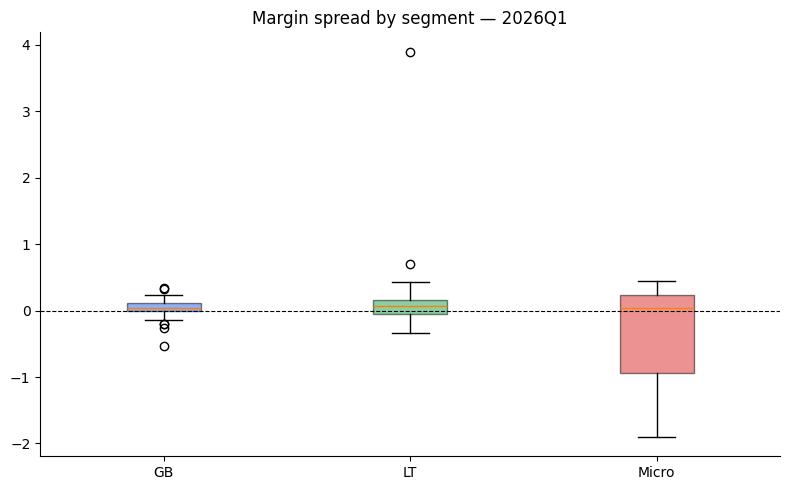

In [43]:
fig, ax = plt.subplots(figsize=(8,5))
data = [latest_ifrs.loc[latest_ifrs.segment==s,'margin'].dropna() for s in ['GB','LT','Micro']]
bp = ax.boxplot(data, labels=['GB','LT','Micro'], patch_artist=True)
for patch, seg in zip(bp['boxes'], ['GB','LT','Micro']):
    patch.set_facecolor(COLORS[seg]); patch.set_alpha(0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Margin spread by segment — 2026Q1')
plt.tight_layout(); plt.show()


### 1.5 Cross-quarter trend — YTD (as reported) vs discrete (de-cumulated)

Margin is a same-period ratio (both numerator and denominator cumulative together), so it's
less distorted by the YTD convention than a raw total would be — but we build the discrete
view too, to check whether flagged anomalies are quarter-specific events or YTD artifacts.

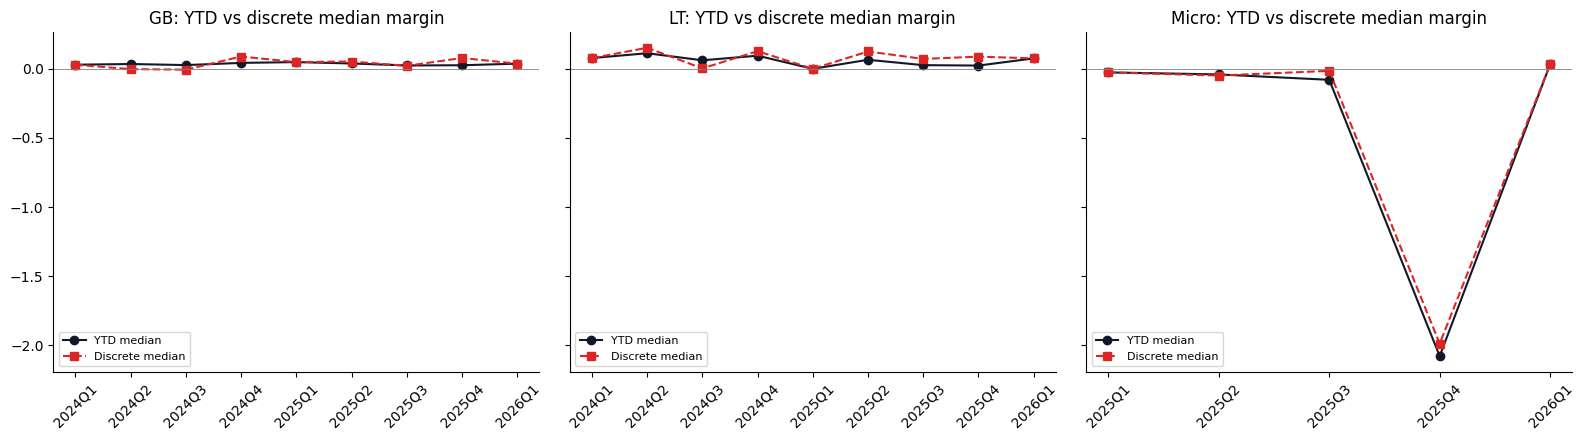

Re-checking flagged anomalies on the DISCRETE basis:
GB 2025Q3:


,quarter,segment,median,mean
14,2025Q3,GB,0.02,0.06


Micro 2025Q4:


,quarter,segment,median,mean
19,2025Q4,Micro,-1.99,-3.31


In [44]:
ifrs_d = decumulate(ifrs, 'insurance_revenue', 'revenue_discrete')
ifrs_d = decumulate(ifrs_d, 'insurance_service_result', 'isr_discrete')
ifrs_d['margin_discrete'] = ifrs_d['isr_discrete'] / ifrs_d['revenue_discrete']

trend_ytd = ifrs.groupby(['quarter','segment'])['margin'].agg(median='median', mean='mean').reset_index()
trend_disc = ifrs_d.groupby(['quarter','segment'])['margin_discrete'].agg(median='median', mean='mean').reset_index()

for t in (trend_ytd, trend_disc):
    t['quarter'] = pd.Categorical(t['quarter'], categories=QUARTER_ORDER, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(16,4.5), sharey=True)
for ax, seg in zip(axes, ['GB','LT','Micro']):
    y = trend_ytd[trend_ytd.segment==seg].sort_values('quarter')
    d = trend_disc[trend_disc.segment==seg].sort_values('quarter')
    ax.plot(y['quarter'], y['median'], marker='o', color='#111827', label='YTD median')
    ax.plot(d['quarter'], d['median'], marker='s', color='#dc2626', linestyle='--', label='Discrete median')
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.set_title(f'{seg}: YTD vs discrete median margin')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Re-checking flagged anomalies on the DISCRETE basis:')
print('GB 2025Q3:'); display(trend_disc[(trend_disc.segment=='GB')&(trend_disc.quarter=='2025Q3')])
print('Micro 2025Q4:'); display(trend_disc[(trend_disc.segment=='Micro')&(trend_disc.quarter=='2025Q4')])


### 1.6 Bivariate — size vs profitability

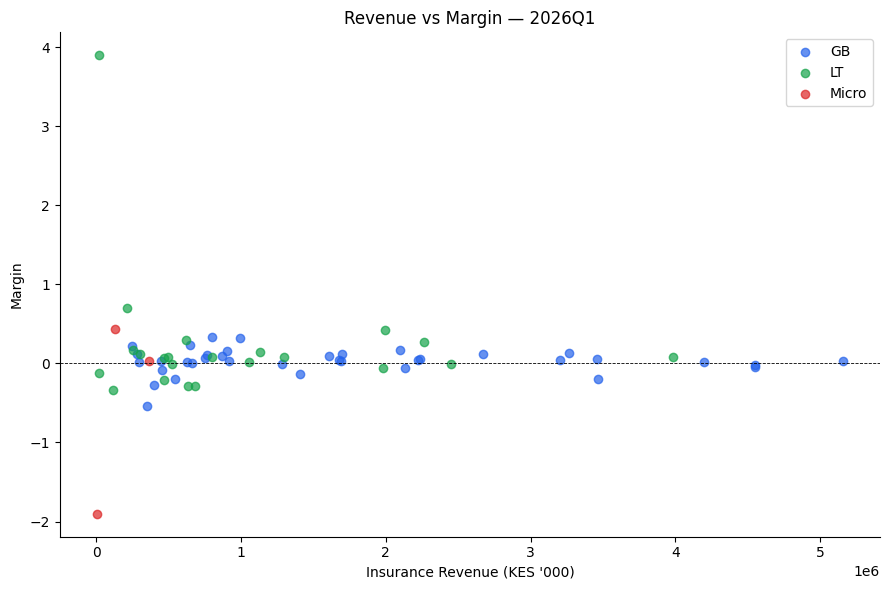

GB: r = -0.012 (n=37)
LT: r = -0.169 (n=22)
Micro: r = 0.654 (n=3)


In [45]:
fig, ax = plt.subplots(figsize=(9,6))
for seg in ['GB','LT','Micro']:
    sub = latest_ifrs[latest_ifrs.segment==seg]
    ax.scatter(sub['insurance_revenue'], sub['margin'], label=seg, color=COLORS[seg], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_xlabel("Insurance Revenue (KES '000)"); ax.set_ylabel('Margin')
ax.set_title('Revenue vs Margin — 2026Q1'); ax.legend()
plt.tight_layout(); plt.show()

for seg in ['GB','LT','Micro']:
    sub = latest_ifrs[latest_ifrs.segment==seg].dropna(subset=['insurance_revenue','margin'])
    if len(sub) > 2:
        print(f'{seg}: r = {sub.insurance_revenue.corr(sub.margin):.3f} (n={len(sub)})')


### 1.7 Completeness check

In [46]:
coverage = ifrs.groupby(['quarter','segment'])['company_id'].nunique().reset_index(name='n')
coverage['quarter'] = pd.Categorical(coverage['quarter'], categories=QUARTER_ORDER, ordered=True)
display(coverage.pivot(index='quarter', columns='segment', values='n').sort_index())


segment,GB,LT,Micro
quarter,,,
2024Q1,42.00,29.00,NaN
2024Q2,42.00,29.00,NaN
2024Q3,41.00,29.00,NaN
2024Q4,42.00,29.00,NaN
2025Q1,42.00,29.00,7.00
2025Q2,43.00,29.00,7.00
2025Q3,44.00,29.00,7.00
2025Q4,43.00,28.00,7.00
2026Q1,41.00,26.00,7.00


---
# Part 2 — Loss Ratio & Underwriting Performance (GB / Micro)

Using statutory underwriting-account figures: loss ratio, commission ratio, expense ratio,
and the **combined ratio** (sum of all three — the standard general-insurance headline
profitability number; under 100% = underwriting profit, over 100% = underwriting loss).

In [47]:
uw['loss_ratio'] = uw['incurred_claims'] / uw['net_earned_premium_income']
uw['commission_ratio'] = uw['net_commissions'] / uw['net_earned_premium_income']
uw['expense_ratio'] = uw['expense_of_management'] / uw['net_earned_premium_income']
uw['combined_ratio'] = uw['loss_ratio'] + uw['commission_ratio'] + uw['expense_ratio']

latest_uw = uw[uw['quarter']=='2026Q1']


### 2.1 – 2.2 Univariate & ratio distributions (2026Q1)

In [48]:
for seg in ['GB','Micro']:
    sub = latest_uw[latest_uw.segment==seg]
    print(f'--- {seg} (n={len(sub)}) ---')
    for col in ['loss_ratio','commission_ratio','expense_ratio','combined_ratio']:
        print(f'  {col}: median={sub[col].median():.2f}  mean={sub[col].mean():.2f}  '
              f'p25={sub[col].quantile(.25):.2f}  p75={sub[col].quantile(.75):.2f}')


--- GB (n=41) ---
  loss_ratio: median=0.71  mean=0.69  p25=0.55  p75=0.78
  commission_ratio: median=0.09  mean=0.10  p25=0.07  p75=0.13
  expense_ratio: median=0.29  mean=0.34  p25=0.18  p75=0.43
  combined_ratio: median=1.05  mean=1.12  p25=0.94  p75=1.23
--- Micro (n=7) ---
  loss_ratio: median=0.29  mean=0.39  p25=0.25  p75=0.48
  commission_ratio: median=0.09  mean=0.11  p25=0.09  p75=0.13
  expense_ratio: median=0.29  mean=0.62  p25=0.28  p75=0.79
  combined_ratio: median=1.05  mean=1.12  p25=0.89  p75=1.31


### 2.3 Outliers (revenue-floor filtered)

In [49]:
floor = latest_uw.loc[latest_uw.segment=='GB','net_earned_premium_income'].quantile(.10)
gb = latest_uw[(latest_uw.segment=='GB') & (latest_uw.net_earned_premium_income >= floor)]
print('Worst GB combined ratios:')
display(gb.nlargest(5,'combined_ratio')[['company_name','net_earned_premium_income','loss_ratio','combined_ratio']])
print('Best GB combined ratios:')
display(gb.nsmallest(5,'combined_ratio')[['company_name','net_earned_premium_income','loss_ratio','combined_ratio']])


Worst GB combined ratios:


,company_name,net_earned_premium_income,loss_ratio,combined_ratio
386,KENYA ORIENT INSURANCE,"128,701.10",1.32,2.51
391,OCCIDENTAL INSURANCE COMPANY,"122,155.01",1.39,2.29
375,DIRECTLINE ASSURANCE COMPANY,"738,125.74",1.23,1.67
398,TAUSI ASSURANCE COMPANY,"294,911.86",0.77,1.54
381,GEMINIA INSURANCE COMPANY,"801,428.53",1.14,1.53


Best GB combined ratios:


,company_name,net_earned_premium_income,loss_ratio,combined_ratio
371,BUPA GLOBAL INSURANCE,"490,264.35",0.03,-0.07
377,EQUITY HEALTH INSURANCE LIMITED,"189,138.15",0.07,0.45
402,CONTINENTAL REINSURANCE,"1,336,678.50",0.29,0.75
396,STAR DISCOVER INSURANCE,"396,881.47",0.41,0.86
405,KENYA REINSURANCE CORPORATION,"2,806,022.16",0.53,0.86


### IFRS 17 margin vs statutory combined ratio — cross-check

Two independently-derived views of GB profitability, compared directly. They should broadly
agree; where they don't, it's a genuine accounting-framework divergence worth flagging on
the dashboard, not a data error.

In [50]:
ifrs_gb = ifrs[ifrs.source_fingerprint_id=='PL_GB_SUMMARY'][['company_id','period_id','margin']]
uw_gb = uw[uw.source_fingerprint_id=='GB_COMBINED_PREMIUM_SUMMARY'][['company_id','period_id','combined_ratio','company_name','quarter']]
cmp = ifrs_gb.merge(uw_gb, on=['company_id','period_id'])
cmp['stat_margin'] = 1 - cmp['combined_ratio']
cmp_latest = cmp[cmp.quarter=='2026Q1']

corr = cmp_latest['margin'].corr(cmp_latest['stat_margin'])
print(f'Correlation, IFRS17 margin vs statutory margin (2026Q1): {corr:.3f}  (n={len(cmp_latest)})')

disagree = cmp_latest[((cmp_latest.margin>0)&(cmp_latest.stat_margin<0)) | ((cmp_latest.margin<0)&(cmp_latest.stat_margin>0))]
print(f'Companies where the two views disagree on profit/loss direction: {len(disagree)}/{len(cmp_latest)} '
      f'({len(disagree)/len(cmp_latest):.0%})')
display(disagree[['company_name','margin','stat_margin','combined_ratio']].round(3))


Correlation, IFRS17 margin vs statutory margin (2026Q1): 0.624  (n=41)
Companies where the two views disagree on profit/loss direction: 16/41 (39%)


,company_name,margin,stat_margin,combined_ratio
339,AAR INSURANCE KENYA,0.04,-0.01,1.01
340,AFRICAN MERCHANT ASSURANCE,0.33,-0.13,1.13
342,BRITAM GENERAL INSURANCE,0.06,-0.05,1.05
344,CANNON GENERAL INSURANCE,0.01,-0.12,1.11
345,CIC GENERAL INSURANCE COMPANY,0.04,-0.04,1.03
347,DIRECTLINE ASSURANCE COMPANY,0.11,-0.67,1.67
348,EQUITY GENERAL INSURANCE LIMITED,0.22,-0.44,1.44
350,FIDELITY SHIELD INSURANCE,-0.00,0.06,0.94
351,FIRST ASSURANCE COMPANY,0.03,-0.10,1.10
355,INTRA-AFRICA ASSURANCE,0.09,-0.16,1.16


### 2.4 Segment comparison

C:\Users\Admin\AppData\Local\Temp\ipykernel_16484\3499918191.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['GB','Micro'], patch_artist=True)


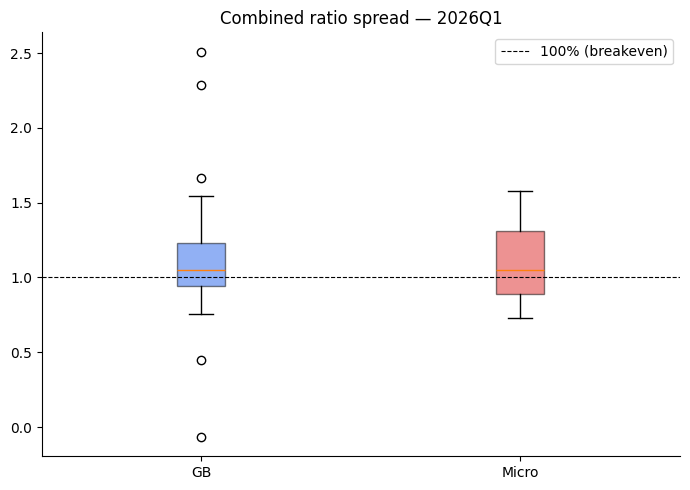

In [51]:
fig, ax = plt.subplots(figsize=(7,5))
data = [latest_uw.loc[latest_uw.segment==s,'combined_ratio'].dropna() for s in ['GB','Micro']]
bp = ax.boxplot(data, labels=['GB','Micro'], patch_artist=True)
for patch, seg in zip(bp['boxes'], ['GB','Micro']):
    patch.set_facecolor(COLORS[seg]); patch.set_alpha(0.5)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='100% (breakeven)')
ax.set_title('Combined ratio spread — 2026Q1'); ax.legend()
plt.tight_layout(); plt.show()


### 2.5 Cross-quarter trend — median combined ratio

In [52]:
trend_cr = uw.groupby(['quarter','segment'])['combined_ratio'].median().reset_index()
trend_cr['quarter'] = pd.Categorical(trend_cr['quarter'], categories=QUARTER_ORDER, ordered=True)
display(trend_cr.sort_values(['segment','quarter']).pivot(index='quarter',columns='segment',values='combined_ratio').round(2))


segment,GB,Micro
quarter,,
2024Q1,1.05,NaN
2024Q2,1.04,NaN
2024Q3,1.02,NaN
2024Q4,1.02,NaN
2025Q1,1.01,0.95
2025Q2,1.03,1.14
2025Q3,1.02,0.62
2025Q4,1.03,7.11
2026Q1,1.05,1.05


### 2.6 Bivariate — size vs combined ratio

In [53]:
for seg in ['GB','Micro']:
    sub = latest_uw[latest_uw.segment==seg].dropna(subset=['net_earned_premium_income','combined_ratio'])
    if len(sub) > 2:
        print(f'{seg}: r = {sub.net_earned_premium_income.corr(sub.combined_ratio):.3f} (n={len(sub)})')


GB: r = -0.179 (n=37)
Micro: r = -0.416 (n=3)


---
# Part 3 — Market Share & Concentration (GB / Micro)

Built on `gross_direct_premium`. **De-cumulation is essential here** — cumulative YTD
figures make concentration look artificially different across quarters as an artifact of
reporting completeness, not real market structure (confirmed below).

In [54]:
uw_d = decumulate(uw, 'gross_direct_premium', 'gdp_discrete')

neg = uw_d[uw_d['gdp_discrete'] < 0]
print(f'Rows with impossible negative discrete GDP after zero-as-missing cleanup: {len(neg)}')
if len(neg):
    display(neg[['company_name','quarter','gross_direct_premium','gdp_discrete']])


Rows with impossible negative discrete GDP after zero-as-missing cleanup: 0


### 3.1 – 3.2 Market share, cumulative (YTD) vs discrete

In [55]:
def hhi(x): return ((x.dropna()*100)**2).sum()
def top3(x): return x.dropna().nlargest(3).sum()

uw['seg_total_ytd'] = uw.groupby(['quarter','segment'])['gross_direct_premium'].transform('sum')
uw['share_ytd'] = uw['gross_direct_premium'] / uw['seg_total_ytd']

uw_d['seg_total_disc'] = uw_d.groupby(['quarter','segment'])['gdp_discrete'].transform('sum')
uw_d['share_discrete'] = uw_d['gdp_discrete'] / uw_d['seg_total_disc']

hhi_ytd = uw.groupby(['quarter','segment'])['share_ytd'].agg(hhi=hhi, top3_share=top3).reset_index()
hhi_disc = uw_d.groupby(['quarter','segment'])['share_discrete'].agg(hhi=hhi, top3_share=top3).reset_index()
for t in (hhi_ytd, hhi_disc):
    t['quarter'] = pd.Categorical(t['quarter'], categories=QUARTER_ORDER, ordered=True)

print('HHI — cumulative YTD (distorted by reporting-completeness artifacts):')
display(hhi_ytd.sort_values(['segment','quarter']).pivot(index='quarter',columns='segment',values='hhi').round(0))
print()
print('HHI — discrete quarterly (corrected):')
display(hhi_disc.sort_values(['segment','quarter']).pivot(index='quarter',columns='segment',values='hhi').round(0))


HHI — cumulative YTD (distorted by reporting-completeness artifacts):


segment,GB,Micro
quarter,,
2024Q1,609.00,NaN
2024Q2,569.00,NaN
2024Q3,580.00,NaN
2024Q4,564.00,NaN
2025Q1,573.00,"6,543.00"
2025Q2,499.00,"6,543.00"
2025Q3,487.00,"6,046.00"
2025Q4,528.00,"6,121.00"
2026Q1,548.00,"5,262.00"



HHI — discrete quarterly (corrected):


segment,GB,Micro
quarter,,
2024Q1,609.00,NaN
2024Q2,558.00,NaN
2024Q3,540.00,NaN
2024Q4,605.00,NaN
2025Q1,573.00,"6,543.00"
2025Q2,578.00,"6,544.00"
2025Q3,476.00,"5,184.00"
2025Q4,570.00,"6,170.00"
2026Q1,548.00,"5,262.00"


### 3.3 Top players (2026Q1, discrete)

In [56]:
latest_d = uw_d[uw_d['quarter']=='2026Q1']
for seg in ['GB','Micro']:
    sub = latest_d[latest_d.segment==seg]
    top = sub.nlargest(5, 'share_discrete')
    print(f'--- {seg} top players (discrete, 2026Q1) ---')
    display(top[['company_name','gdp_discrete','share_discrete']].round(4))


--- GB top players (discrete, 2026Q1) ---


,company_name,gdp_discrete,share_discrete
105,CIC GENERAL INSURANCE COMPANY,"7,412,727.02",0.09
87,GA INSURANCE COMPANY,"7,314,908.91",0.09
300,OLD MUTUAL GENERAL INSURANCE,"7,300,993.00",0.09
395,APA INSURANCE LIMITED,"7,072,321.72",0.09
123,JUBILEE HEALTH INSURANCE,"4,956,327.13",0.06


--- Micro top players (discrete, 2026Q1) ---


,company_name,gdp_discrete,share_discrete
360,BRITAM MICRO INSURANCE,"334,199.29",0.66
381,TURACO MICRO INSURANCE,"152,355.65",0.30
375,CIC MICRO INSURANCE,"20,591.72",0.04
365,BIRDVIEW MICRO INSURANCE,0.00,0.00
370,APA MICRO INSURANCE,0.00,0.00


### 3.4 Seasonal pattern — discrete quarterly total premium

GB shows a repeating pattern: Q1 is consistently the largest discrete quarter, every year —
likely driven by corporate renewal cycles concentrated around January.

segment,GB,Micro
quarter,,
2024Q1,"69,685,607.00",NaN
2024Q2,"48,063,929.00",NaN
2024Q3,"47,683,698.00",NaN
2024Q4,"34,553,277.00",NaN
2025Q1,"74,780,805.00","521,245.00"
2025Q2,"53,379,919.00","500,451.00"
2025Q3,"58,347,779.00","461,756.00"
2025Q4,"40,734,686.00","644,968.00"
2026Q1,"80,872,202.00","507,147.00"


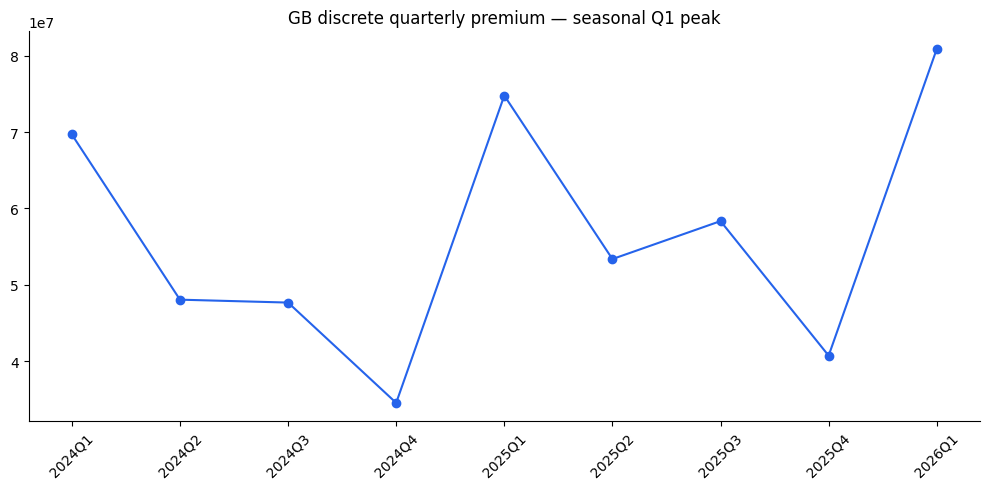

In [57]:
tot = uw_d.groupby(['quarter','segment'])['gdp_discrete'].sum().reset_index()
tot['quarter'] = pd.Categorical(tot['quarter'], categories=QUARTER_ORDER, ordered=True)
pivot = tot.sort_values(['segment','quarter']).pivot(index='quarter', columns='segment', values='gdp_discrete')
display(pivot.round(0))

fig, ax = plt.subplots(figsize=(10,5))
gb_series = pivot['GB'].dropna()
ax.plot(gb_series.index.astype(str), gb_series.values, marker='o', color=COLORS['GB'])
ax.set_title('GB discrete quarterly premium — seasonal Q1 peak')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


### 3.5 Completeness

In [58]:
coverage_uw = uw.groupby(['quarter','segment'])['company_id'].nunique().reset_index(name='n')
coverage_uw['quarter'] = pd.Categorical(coverage_uw['quarter'], categories=QUARTER_ORDER, ordered=True)
display(coverage_uw.pivot(index='quarter', columns='segment', values='n').sort_index())


segment,GB,Micro
quarter,,
2024Q1,42.00,NaN
2024Q2,42.00,NaN
2024Q3,41.00,NaN
2024Q4,42.00,NaN
2025Q1,42.00,7.00
2025Q2,43.00,7.00
2025Q3,44.00,7.00
2025Q4,43.00,7.00
2026Q1,41.00,7.00


---
# Part 4 — Balance Sheet / Solvency (GB / LT / Micro)

Built from the transposed balance-sheet appendices (24 i–iii / 25 i–iv / 26 i in the Q1 2025
workbook — appendix numbers shift every quarter, so these were located by **content**
(sheet title containing "BALANCE SHEETS"), the same principle used throughout the ETL.

Two known IRA naming inconsistencies were coalesced before analysis: `Share Capital` /
`Share Captial` (the typo already documented in this project), and
`Revaluation Reserves` / `Revaluation Reserve` (a segment-level naming difference, not a
typo — GB/Micro use singular, LT uses plural consistently).

**Important scope note:** the ratios below (capital-to-assets, liquidity ratio) are
**composition-based solvency proxies**, not IRA's official Risk-Based Capital solvency
margin — the real regulatory ratio requires risk-weighted asset data not present in this
balance sheet appendix. Labelled as proxies throughout, not to be confused with the
regulatory figure.

In [59]:
bs_raw = pd.read_sql("select * from fact_balance_sheet",engine)

# exclude known placeholder rows that leaked into dim_company (section-header/subtotal
# labels loaded as if they were companies — confirmed present in fact_pl too, not unique
# to balance sheet)
PLACEHOLDER_IDS = [17, 46, 216, 247, 1032, 1054]  # GRAND TOTAL, Reinsurers, TOTAL, Insurers, TOTAL INSURERS, MICROINSURERS
bs_raw = bs_raw[~bs_raw.company_id.isin(PLACEHOLDER_IDS)]
bs_wide=bs_raw.pivot_table(index=['period_id','company_id','segment'], columns='line_item', values='line_value').reset_index()
bs=bs_wide.merge(dim_company[['company_id','company_name']], on='company_id', how='left')

# coalesce known naming-variant duplicates (same IRA inconsistencies found in the raw workbooks)
COALESCE_MAP = {
    'Share Capital': ['Share Capital','Share Captial'],
    'Revaluation Reserves': ['Revaluation Reserves','Revaluation Reserve'],
    'Investment in Unit Trust': ['Investment in Unit Trust','Investment In Unit Trusts'],
}
for canonical, variants in COALESCE_MAP.items():
    present = [v for v in variants if v in bs.columns]
    bs[canonical] = bs[present].bfill(axis=1).iloc[:,0]
    for v in present:
        if v != canonical:
            bs = bs.drop(columns=v)

# reuse the same period/company attachment helper used for ifrs/uw above, so PERIOD_META's
# (year, q, label) tuple format is handled consistently rather than re-implemented here
bs['quarter'] = bs['period_id'].map(PERIOD_META)
assert bs['quarter'].notna().all(), 'Unmapped period_id found — check PERIOD_META'


print('Clean shape:', bs.shape)
print(bs.groupby(['quarter','segment'])['company_id'].nunique().unstack())

# --- integrity check ---
bs['balance_check_diff'] = bs['Total Assets'] - bs['Total Equity And Liabilities']
bad = bs[bs['balance_check_diff'].abs() > 1]
print(f'\nBalance sheet integrity: {len(bs)-len(bad)}/{len(bs)} rows balance exactly.')
if len(bad):
    display(bad[['company_name','segment','quarter','balance_check_diff']].round(1))

# --- solvency proxy ratios ---
bs['capital_to_assets'] = bs['Total Equity'] / bs['Total Assets']
bs['liquid_assets'] = bs[['Cash and Cash Balances','Term Deposits','Government Securites']].sum(axis=1, min_count=1)
bs['liquidity_ratio'] = bs['liquid_assets'] / bs['Total Assets']
bs['equity_to_insurance_liabilities'] = bs['Total Equity'] / bs['Insurance Contract Liabilites']

latest_bs = bs[bs['quarter']=='2026Q1']


Clean shape: (645, 45)
segment              GB    LT  Micro
quarter                             
(2024, 1, 2024Q1) 41.00 28.00    NaN
(2024, 2, 2024Q2) 41.00 28.00    NaN
(2024, 3, 2024Q3) 40.00 28.00    NaN
(2024, 4, 2024Q4) 41.00 28.00    NaN
(2025, 1, 2025Q1) 41.00 28.00   6.00
(2025, 2, 2025Q2) 42.00 28.00   6.00
(2025, 3, 2025Q3) 43.00 28.00   6.00
(2025, 4, 2025Q4) 40.00 27.00   6.00
(2026, 1, 2026Q1) 38.00 25.00   6.00

Balance sheet integrity: 643/645 rows balance exactly.


,company_name,segment,quarter,balance_check_diff
167,EAST AFRICA REINSURANCE,GB,"(2024, 1, 2024Q1)",-1.30
536,GHANA REINSURANCE COMPANY,GB,"(2025, 4, 2025Q4)",73.80


### 4.1 Univariate distributions (2026Q1)

In [60]:
def bs_univariate(frame, col):
    g = frame.groupby('segment')[col]
    return pd.DataFrame({'n':g.count(),'min':g.min(),'median':g.median(),'max':g.max()}).round(0)

print('Total Equity — 2026Q1')
display(bs_univariate(latest_bs, 'Total Equity'))
print('Total Assets — 2026Q1')
display(bs_univariate(latest_bs, 'Total Assets'))


Total Equity — 2026Q1


,n,min,median,max
segment,,,,


Total Assets — 2026Q1


,n,min,median,max
segment,,,,


### 4.2 Derived ratio — capital-to-assets (proxy solvency indicator)

,n,min,p25,median,p75,max
segment,,,,,,


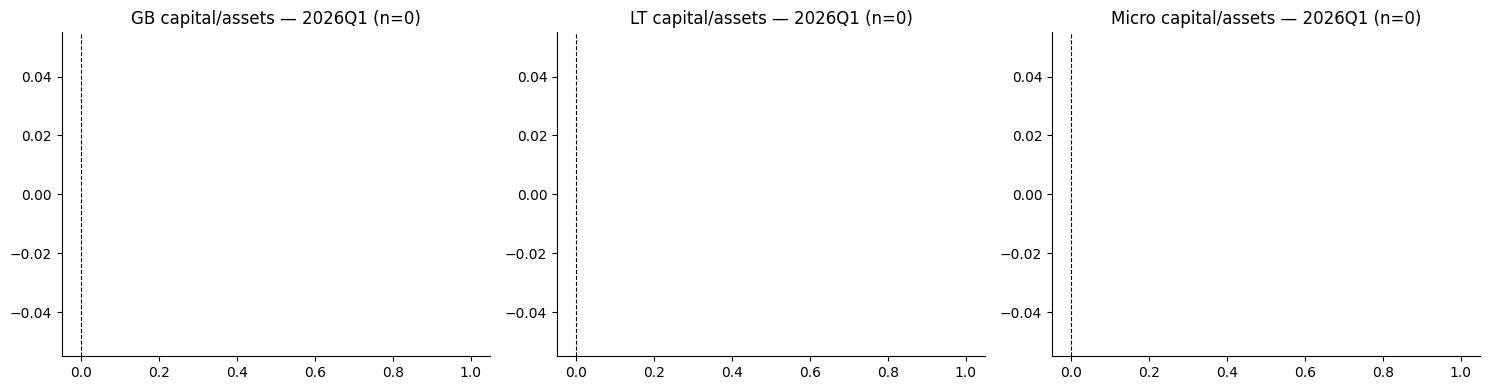

In [61]:
def capital_summary(frame):
    g = frame.groupby('segment')['capital_to_assets']
    return pd.DataFrame({
        'n': g.count(), 'min': g.min(), 'p25': g.quantile(.25), 'median': g.median(),
        'p75': g.quantile(.75), 'max': g.max(),
    }).round(3)

display(capital_summary(latest_bs))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, seg in zip(axes, ['GB','LT','Micro']):
    vals = latest_bs.loc[latest_bs.segment==seg, 'capital_to_assets'].dropna()
    ax.hist(vals, bins=12, color=COLORS[seg], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{seg} capital/assets — 2026Q1 (n={len(vals)})')
plt.tight_layout(); plt.show()


### 4.3 Outliers — negative equity, and how long it's persisted (the headline finding)

A single quarter's negative equity can be a blip; the same company negative for 8+
consecutive quarters is a structurally different situation. Both matter, but they're not
the same finding — duration is shown alongside the current snapshot rather than collapsed
into one number.

In [62]:
neg_equity = latest_bs[latest_bs['Total Equity'] < 0]
print(f'Companies with NEGATIVE Total Equity (2026Q1): {len(neg_equity)}')
display(neg_equity[['company_name','segment','Total Equity','Total Assets','capital_to_assets']].round(0))

print()
print('Full 9-quarter history — which quarters was each company negative-equity in:')
neg_history = (bs[bs['Total Equity']<0]
               .groupby(['company_name','segment'])['quarter']
               .apply(lambda s: sorted(s.tolist(), key=lambda q: QUARTER_ORDER.index(q)))
               .reset_index()
               .rename(columns={'quarter':'negative_equity_quarters'}))
neg_history['n_quarters_negative'] = neg_history['negative_equity_quarters'].apply(len)
display(neg_history.sort_values('n_quarters_negative', ascending=False))


Companies with NEGATIVE Total Equity (2026Q1): 0


,company_name,segment,Total Equity,Total Assets,capital_to_assets



Full 9-quarter history — which quarters was each company negative-equity in:


ValueError: list.index(x): x not in list

### 4.4 Segment comparison

/tmp/ipykernel_198/1402171785.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['GB','LT','Micro'], patch_artist=True)


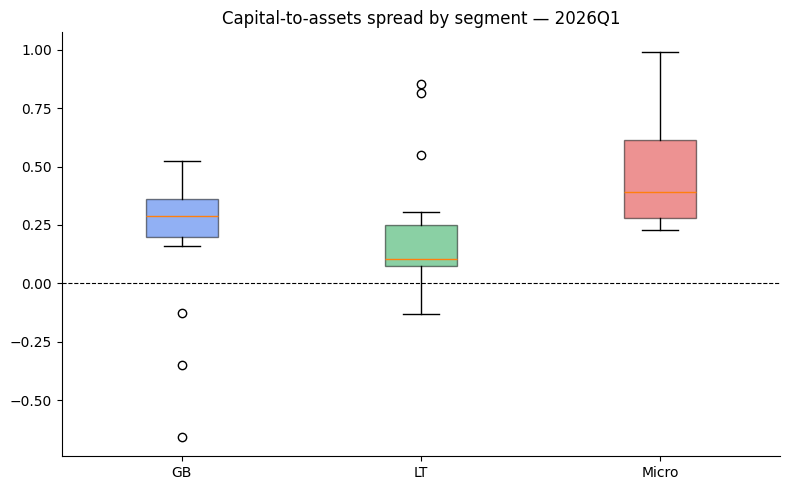

LT's lower median is expected: most of an LT balance sheet is the Life Fund liability owed to policyholders, not equity, by design of fund accounting.


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
data = [latest_bs.loc[latest_bs.segment==s,'capital_to_assets'].dropna() for s in ['GB','LT','Micro']]
bp = ax.boxplot(data, labels=['GB','LT','Micro'], patch_artist=True)
for patch, seg in zip(bp['boxes'], ['GB','LT','Micro']):
    patch.set_facecolor(COLORS[seg]); patch.set_alpha(0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Capital-to-assets spread by segment — 2026Q1')
plt.tight_layout(); plt.show()
print("LT's lower median is expected: most of an LT balance sheet is the Life Fund "
      "liability owed to policyholders, not equity, by design of fund accounting.")


### 4.5 Cross-quarter (3 quarters available — 2024Q1, 2025Q1, 2026Q1 only, since
balance sheet appendices are only present in the Q1 workbooks we've processed so far)

In [ ]:
trend_bs = bs.groupby(['quarter','segment'])['capital_to_assets'].median().reset_index()
display(trend_bs.pivot(index='quarter', columns='segment', values='capital_to_assets').round(3))


segment,GB,LT,Micro
quarter,,,
2024Q1,0.36,0.12,NaN
2024Q2,0.33,0.12,NaN
2024Q3,0.33,0.12,NaN
2024Q4,0.38,0.12,NaN
2025Q1,0.33,0.11,0.35
2025Q2,0.33,0.11,0.30
2025Q3,0.34,0.12,0.61
2025Q4,0.37,0.11,0.49
2026Q1,0.29,0.11,0.39


### 4.6 Bivariate — size vs capital strength

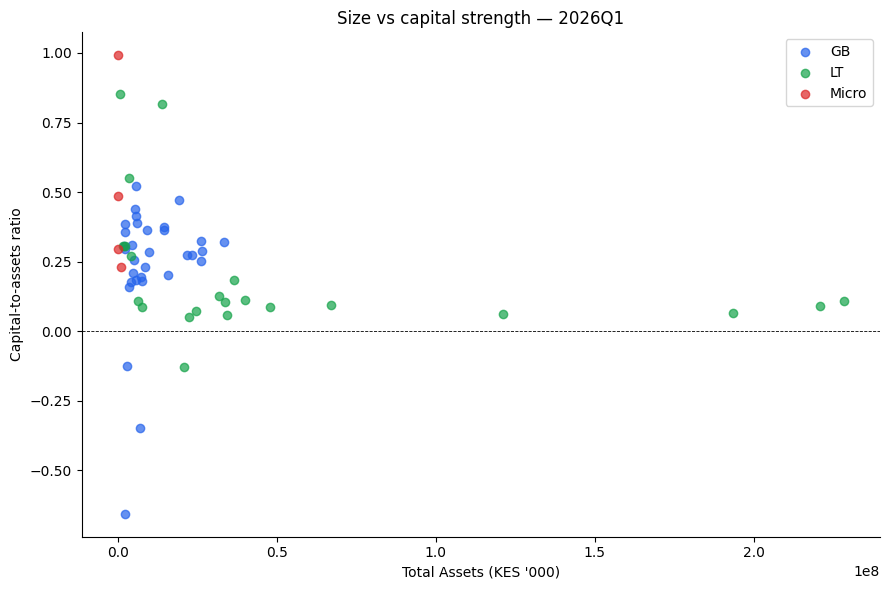

In [ ]:
fig, ax = plt.subplots(figsize=(9,6))
for seg in ['GB','LT','Micro']:
    sub = latest_bs[latest_bs.segment==seg]
    ax.scatter(sub['Total Assets'], sub['capital_to_assets'], label=seg, color=COLORS[seg], alpha=0.7)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_xlabel("Total Assets (KES '000)"); ax.set_ylabel('Capital-to-assets ratio')
ax.set_title('Size vs capital strength — 2026Q1'); ax.legend()
plt.tight_layout(); plt.show()


### 4.7 Completeness

In [ ]:
cov_bs = bs.groupby(['quarter','segment'])['company_id'].nunique().reset_index(name='n')
display(cov_bs.pivot(index='quarter', columns='segment', values='n'))


segment,GB,LT,Micro
quarter,,,
2024Q1,41.00,28.00,NaN
2024Q2,41.00,28.00,NaN
2024Q3,40.00,28.00,NaN
2024Q4,41.00,28.00,NaN
2025Q1,41.00,28.00,6.00
2025Q2,42.00,28.00,6.00
2025Q3,43.00,28.00,6.00
2025Q4,40.00,27.00,6.00
2026Q1,38.00,25.00,6.00


---
# Consolidated Data-Quality Findings (all sections)

1. **IRA's Reliance & Limitations disclaimer text is stale** — references non-submission
   from an earlier quarter than the file it's found in, and lists at least one company as
   excluded that is actually present in the data. Not reliable as a machine-readable
   exclusion list.
2. **Cumulative YTD reporting convention**, confirmed against IRA's own report titles and
   published totals — discrete-quarter figures must be derived, not read directly.
3. **Zero following a positive cumulative figure is very likely non-submission recorded as
   zero, not a genuine drop to nil** — cleaned before de-cumulating throughout this
   notebook; 7 rows would otherwise have produced impossible negative discrete-quarter GDP.
4. **Denominator-artifact outliers**: tiny-revenue companies can show extreme ratios (e.g.
   margin > 100%) purely from a small denominator — a minimum-size floor is applied before
   ranking "best/worst performer" anywhere in this notebook.
5. **IFRS 17 margin and statutory combined ratio disagree on profit/loss direction for a
   meaningful share of GB companies** — both are legitimate, differently-defined metrics;
   the dashboard should show both rather than pick one as "the truth."
6. **LT has no underwriting-account equivalent by design** (fund accounting, not
   underwriting accounting) — Appendix 14's Life Fund data isn't in any fact table yet and
   needs its own schema, not a retrofit into the GB-shaped underwriting columns.
7. **Balance sheet appendix numbering shifts every quarter just like everything else**
   (Appendix 21/22 in 2024 → 24/25/26 in 2025 → 4/5/6 in 2026) — extracted by content
   detection (title containing "BALANCE SHEETS"), not position, consistent with the ETL's
   fingerprinting approach.
8. **Two more IRA naming inconsistencies found and coalesced**: `Share Capital` /
   `Share Captial` (typo, matches what was already known from prior exploration) and
   `Revaluation Reserves` / `Revaluation Reserve` (singular vs plural, a genuine
   segment-level convention difference — GB/Micro use singular, LT plural — not a typo).
9. **Six placeholder rows (`GRAND TOTAL`, `Reinsurers`, `TOTAL`, `Insurers`,
   `TOTAL INSURERS`, `MICROINSURERS`) were loaded into `dim_company` as if they were real
   companies**, and the same placeholder `company_id`s leak into `fact_pl` (49 rows) —
   confirmed to be the source of the unexplained 63.5M GB revenue outlier flagged in Part 1.
   **Parts 1–3 of this notebook were built before this was found and do not have the fix
   applied** — they should be re-run with the same `PLACEHOLDER_IDS` exclusion used in
   Part 4 before being trusted for threshold-setting.

# Open items carried into the thresholds-setting phase

- Segment-specific thresholds are needed — GB, LT, and Micro have structurally different
  margin/ratio distributions; a single industry-wide band would misrepresent at least one
  segment.
- GB's combined ratio has run above 100% at the median in every quarter observed — any
  "healthy" threshold needs to be benchmarked against Kenya's actual market, not a generic
  textbook rule.
- Decide how IFRS 17 margin and statutory combined ratio are jointly represented on the
  dashboard (both shown, one primary + one secondary, or the divergence itself as a metric).
- Micro's severe concentration (HHI ~5,000–6,500) is a real, structural market feature, not
  an artifact — worth a dedicated concentration-risk callout for that segment.
- **Negative-equity companies (Directline, Kenya Orient, MUA in GB; Madison in LT) are
  cross-validated distress signals across three independent metrics** (margin, combined
  ratio, and now equity) — a strong candidate for a dedicated "companies to watch" view on
  the dashboard rather than burying it inside a general distribution chart.
- Balance sheet data is currently only available for Q1 of each year (2024/2025/2026) — the
  cross-quarter solvency trend is much thinner than the P&L/loss-ratio/market-share trends,
  which have all 9 quarters. Worth backfilling other quarters' balance sheets if solvency
  trend analysis matters as much as the profitability trend work.
